In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/data.csv")
print("Shape:", df.shape)
df.head()


Shape: (150000, 12)


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


# Credit Risk Prediction (Give Me Some Credit) with XAI (SHAP)

**Dataset:** Give Me Some Credit (Kaggle)  
**Goal:** Predict `SeriousDlqin2yrs` (1 = default) and explain predictions using SHAP.

Steps:
1. Load & explore data  
2. Handle missing values, scaling  
3. Deal with class imbalance (SMOTE)  
4. Train XGBoost classifier  
5. Evaluate with ROC-AUC, confusion matrix  
6. Explain model using SHAP (global + local)


In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from imblearn.over_sampling import SMOTE

import xgboost as xgb
import shap
import joblib

# For nicer plots
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [ ]:
DATA_PATH = "/content/cs-training.csv"  # <-- change if your path is different

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (150000, 12)


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [ ]:
df.columns


Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [ ]:
# Drop useless index-like column
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Separate target
target_col = "SeriousDlqin2yrs"
X = df.drop(columns=[target_col])
y = df[target_col]

print("New shape:", X.shape)
print("Target distribution:")
print(y.value_counts())
print("\nTarget distribution (normalized):")
print(y.value_counts(normalize=True))


New shape: (150000, 10)
Target distribution:
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Target distribution (normalized):
SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


In [ ]:
df.isnull().sum()


,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,29731
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0
NumberOfTime60-89DaysPastDueNotWorse,0


In [ ]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


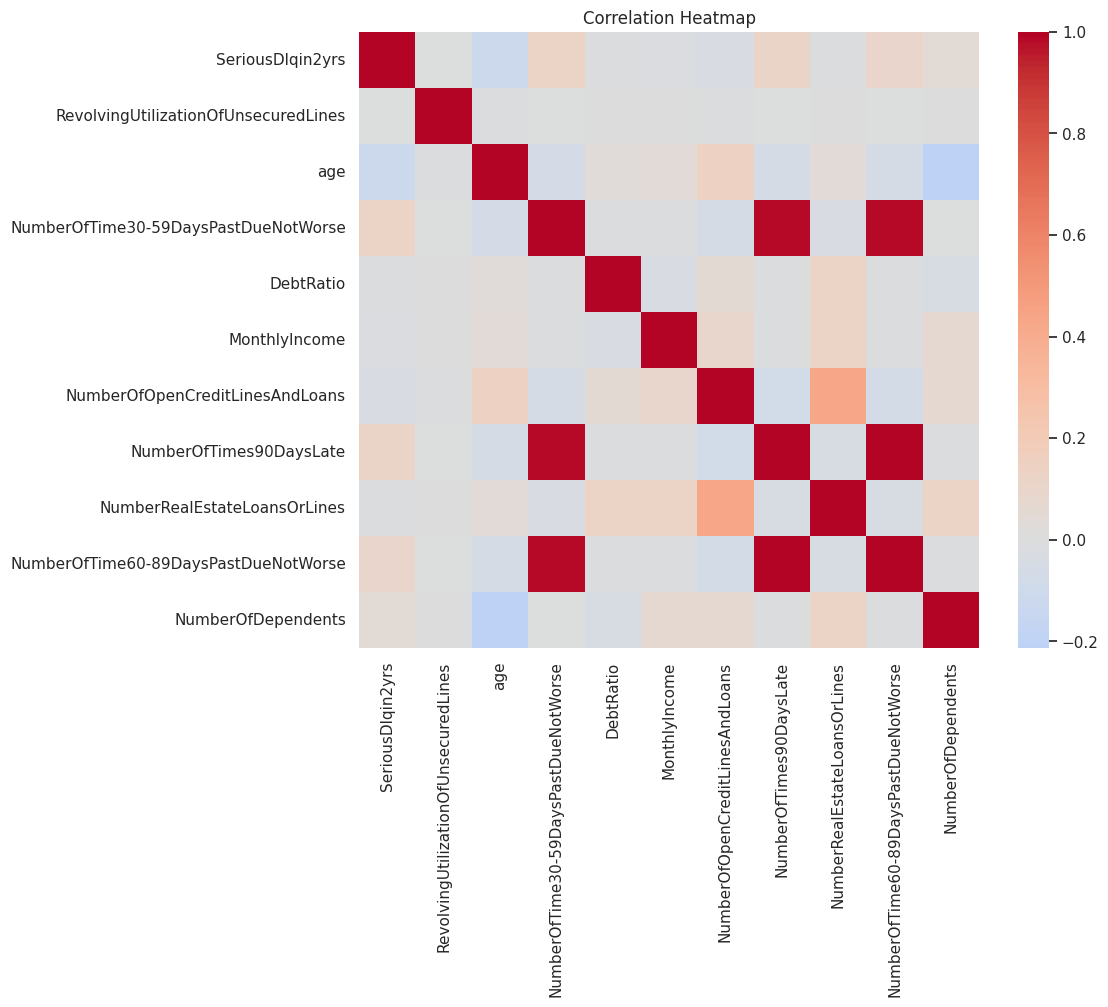

In [ ]:
# Correlation heatmap (for top correlations)
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape


((120000, 10), (30000, 10))

In [ ]:
numeric_features = X.columns.tolist()
numeric_features


['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents']

In [ ]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Fit on train, transform both
X_train_prep = num_pipeline.fit_transform(X_train)
X_test_prep = num_pipeline.transform(X_test)

X_train_prep.shape, X_test_prep.shape


((120000, 10), (30000, 10))

In [ ]:
print("Class counts before SMOTE:", np.bincount(y_train))

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_prep, y_train)

print("Class counts after SMOTE:", np.bincount(y_train_bal))


Class counts before SMOTE: [111979   8021]
Class counts after SMOTE: [111979 111979]


In [ ]:
print("Class counts before SMOTE:", np.bincount(y_train))

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_prep, y_train)

print("Class counts after SMOTE:", np.bincount(y_train_bal))


Class counts before SMOTE: [111979   8021]
Class counts after SMOTE: [111979 111979]


In [ ]:
model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    tree_method="hist"  # faster; remove if error on your GPU/CPU setup
)

model.fit(X_train_bal, y_train_bal)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Predictions
y_pred_proba = model.predict_proba(X_test_prep)[:, 1]
y_pred = model.predict(X_test_prep)

# ROC-AUC
auc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC:", auc)


ROC-AUC: 0.8464413533054308


In [ ]:
print("Classification report:")
print(classification_report(y_test, y_pred))


Classification report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     27995
           1       0.35      0.47      0.40      2005

    accuracy                           0.91     30000
   macro avg       0.65      0.70      0.67     30000
weighted avg       0.92      0.91      0.91     30000



In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm


array([[26232,  1763],
       [ 1062,   943]])

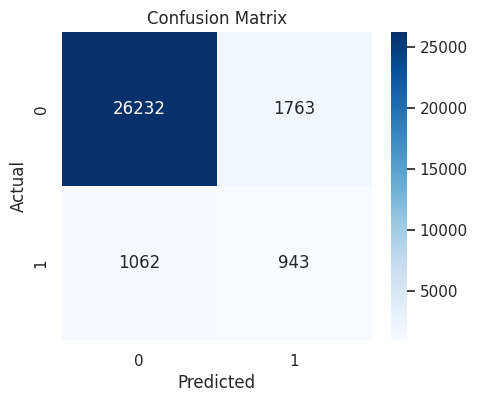

In [ ]:
# Plot confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


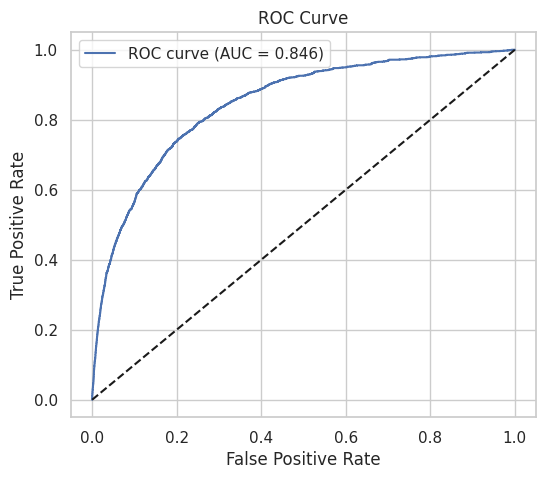

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [ ]:
joblib.dump(model, "xgb_gmsc_model.joblib")
joblib.dump(num_pipeline, "gmsc_preprocessor.joblib")

print("Saved: xgb_gmsc_model.joblib and gmsc_preprocessor.joblib")


Saved: xgb_gmsc_model.joblib and gmsc_preprocessor.joblib


In [ ]:
# Initialize JS if you're in Jupyter Notebook
shap.initjs()

# Feature names
feature_names = X.columns.tolist()

# Build explainer for the trained model
explainer = shap.TreeExplainer(model)

# Use a subset for SHAP to keep it fast
X_test_df = pd.DataFrame(X_test_prep, columns=feature_names)
X_shap = X_test_df.sample(1000, random_state=42)

# Compute SHAP values
shap_values = explainer.shap_values(X_shap)


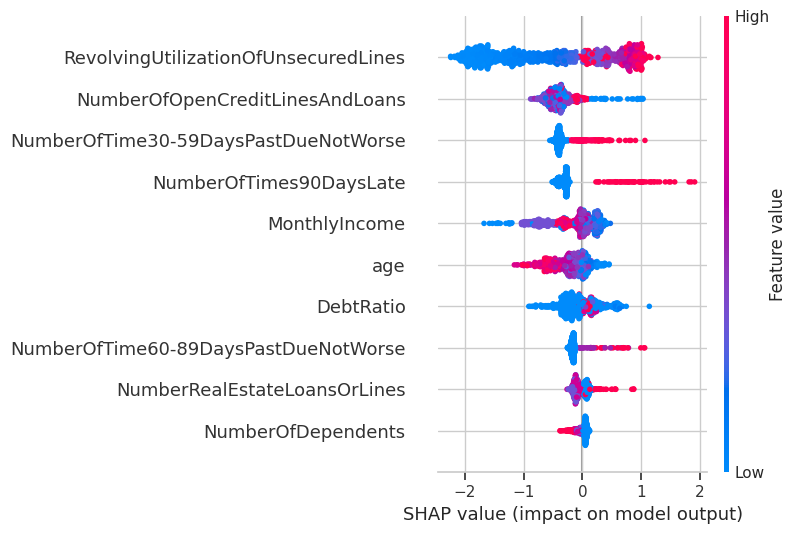

In [ ]:
shap.summary_plot(shap_values, X_shap)


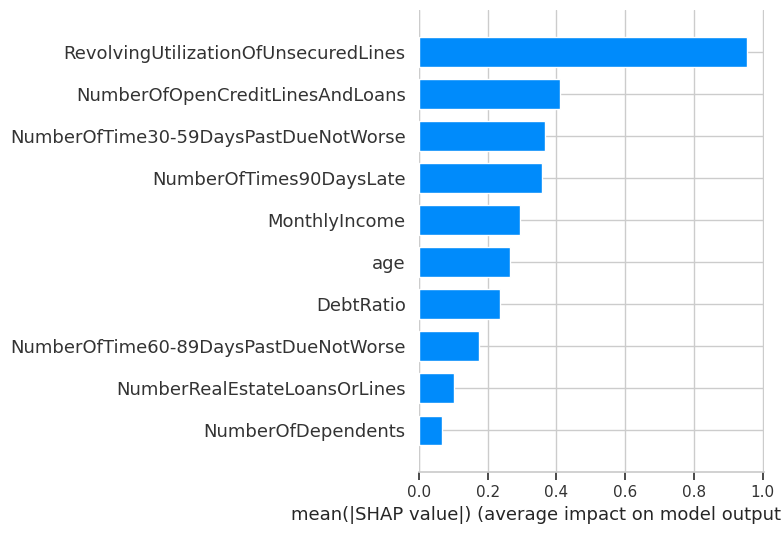

In [ ]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")


In [ ]:
# Pick any instance from the test set
idx = 5  # change index as you like

instance = X_test_df.iloc[[idx]]          # preprocessed features
raw_instance = X_test.iloc[[idx]]         # original values for human reading

display(raw_instance)  # show original feature values


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
86739,0.019643,80,0,29.0,NaN,5,0,0,0,NaN


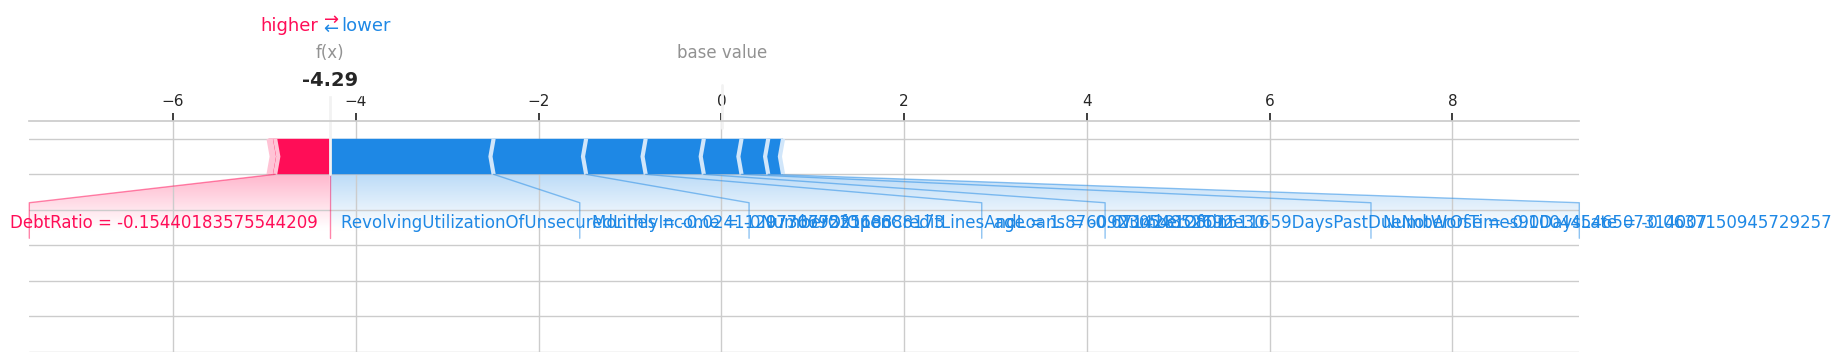

In [ ]:
# SHAP values for that one instance
shap_value_single = explainer.shap_values(instance)

# Force plot with matplotlib (static)
shap.force_plot(
    explainer.expected_value,
    shap_value_single[0, :],
    instance,
    matplotlib=True
)


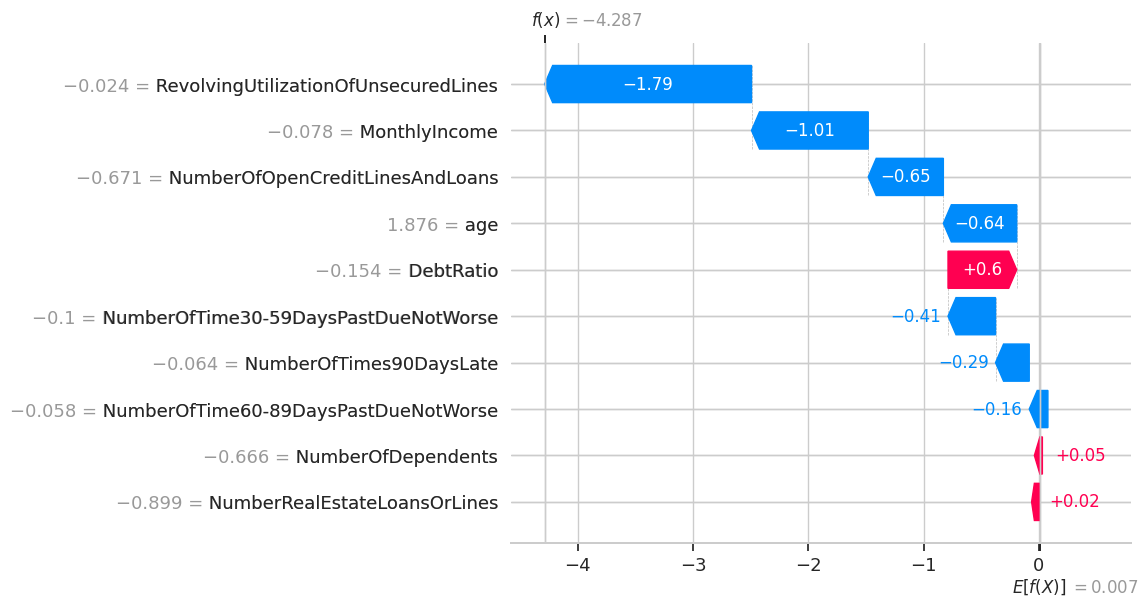

In [ ]:
try:
    exp = shap.Explanation(
        values=shap_value_single[0],
        base_values=explainer.expected_value,
        data=instance.values[0],
        feature_names=feature_names
    )
    shap.plots.waterfall(exp)
except Exception as e:
    print("Waterfall plot not supported in this SHAP version:", e)


In [ ]:
mean_abs_shap = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values(by="mean_abs_shap", ascending=False)

mean_abs_shap.head(10)


,feature,mean_abs_shap
0,RevolvingUtilizationOfUnsecuredLines,0.955403
5,NumberOfOpenCreditLinesAndLoans,0.410969
2,NumberOfTime30-59DaysPastDueNotWorse,0.365205
6,NumberOfTimes90DaysLate,0.357269
4,MonthlyIncome,0.294632
1,age,0.265233
3,DebtRatio,0.235730
8,NumberOfTime60-89DaysPastDueNotWorse,0.174878
7,NumberRealEstateLoansOrLines,0.101635
9,NumberOfDependents,0.068487


In [ ]:
fair_df = X_test.copy()
fair_df["y_true"] = y_test.values
fair_df["y_pred"] = y_pred
fair_df["y_prob"] = y_pred_proba

# Age groups
fair_df["age_group"] = pd.cut(
    fair_df["age"],
    bins=[0, 30, 45, 60, 120],
    labels=["Young", "Adult", "Middle-Aged", "Senior"]
)

# Income groups
fair_df["income_group"] = pd.qcut(
    fair_df["MonthlyIncome"],
    q=4,
    labels=["Low", "Mid-Low", "Mid-High", "High"]
)

# Debt Ratio groups
fair_df["debt_group"] = pd.qcut(
    fair_df["DebtRatio"],
    q=4,
    labels=["Low Debt", "Mid-Low Debt", "Mid-High Debt", "High Debt"]
)

fair_df.head()


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,y_true,y_pred,y_prob,age_group,income_group,debt_group
10682,0.019252,66,0,0.433926,5175.0,13,0,1,0,0.0,0,0,0.035898,Senior,Mid-Low,Mid-High Debt
40173,0.454221,78,0,0.873533,2300.0,7,0,1,0,2.0,0,0,0.119565,Senior,Low,Mid-High Debt
4719,0.077572,59,0,0.172882,10833.0,5,0,1,0,0.0,0,0,0.026703,Middle-Aged,High,Low Debt
81730,0.107864,59,0,0.453692,9900.0,10,0,2,0,0.0,0,0,0.088979,Middle-Aged,High,Mid-High Debt
113639,0.101095,67,0,0.407831,5950.0,14,0,2,0,0.0,0,0,0.086179,Senior,Mid-High,Mid-High Debt


In [ ]:
# Default rate by age group
fair_df.groupby("age_group")["y_true"].mean()


/tmp/ipython-input-3682778265.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fair_df.groupby("age_group")["y_true"].mean()


,y_true
age_group,
Young,0.128531
Adult,0.094969
Middle-Aged,0.066598
Senior,0.027255


In [ ]:
# Default rate by income group
fair_df.groupby("income_group")["y_true"].mean()


/tmp/ipython-input-800061622.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fair_df.groupby("income_group")["y_true"].mean()


,y_true
income_group,
Low,0.094037
Mid-Low,0.077347
Mid-High,0.060986
High,0.044103


In [ ]:
# Default rate by debt group
fair_df.groupby("debt_group")["y_true"].mean()


/tmp/ipython-input-1779578097.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fair_df.groupby("debt_group")["y_true"].mean()


,y_true
debt_group,
Low Debt,0.059867
Mid-Low Debt,0.054000
Mid-High Debt,0.083600
High Debt,0.069867


In [ ]:
def group_recall(df, group_col):
    results = {}
    for g in df[group_col].dropna().unique():
        sub = df[df[group_col] == g]
        tp = ((sub["y_true"] == 1) & (sub["y_pred"] == 1)).sum()
        fn = ((sub["y_true"] == 1) & (sub["y_pred"] == 0)).sum()
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        results[g] = recall
    return pd.Series(results)

group_recall(fair_df, "age_group")


,0
Senior,0.256098
Middle-Aged,0.431373
Young,0.652015
Adult,0.510363


In [ ]:
group_recall(fair_df, "income_group")


,0
Mid-Low,0.526998
Low,0.552398
High,0.287879
Mid-High,0.394521


In [ ]:
group_recall(fair_df, "debt_group")


,0
Mid-High Debt,0.400319
Low Debt,0.585746
High Debt,0.486641
Mid-Low Debt,0.429630


In [ ]:
def false_positive_rate_by_group(df, group_col):
    results = {}
    for g in df[group_col].dropna().unique():
        sub = df[df[group_col] == g]
        fp = ((sub["y_true"] == 0) & (sub["y_pred"] == 1)).sum()
        tn = ((sub["y_true"] == 0) & (sub["y_pred"] == 0)).sum()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        results[g] = fpr
    return pd.Series(results)

false_positive_rate_by_group(fair_df, "age_group")


,0
Senior,0.009567
Middle-Aged,0.053163
Young,0.222582
Adult,0.099905


In [ ]:
false_positive_rate_by_group(fair_df, "income_group")


,0
Mid-Low,0.089444
Low,0.124263
High,0.015729
Mid-High,0.038078


In [ ]:
false_positive_rate_by_group(fair_df, "debt_group")


,0
Mid-High Debt,0.063291
Low Debt,0.085378
High Debt,0.059060
Mid-Low Debt,0.044257


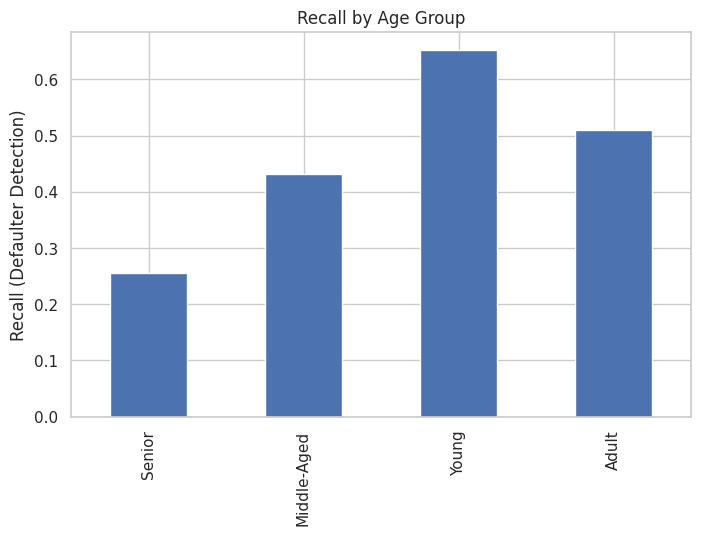

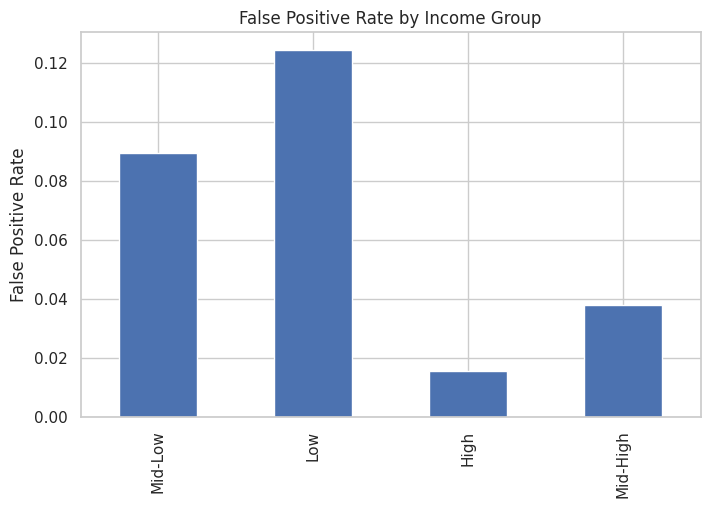

In [ ]:
group_recall(fair_df, "age_group").plot(kind="bar", title="Recall by Age Group")
plt.ylabel("Recall (Defaulter Detection)")
plt.show()

false_positive_rate_by_group(fair_df, "income_group").plot(
    kind="bar", title="False Positive Rate by Income Group"
)
plt.ylabel("False Positive Rate")
plt.show()

